# homolog-search-tools Demo

This notebook explores several use-cases for the python module homolog-search-tools.

1. Interacting with the UniProt API.
2. Computing sequence similarities.
3. Visualizing sequences with sequence similarity networls (SSNs).


## Introduction


In this case study, we are tasked to explore the ADH1 sequence space; ADH1, known as alcohol dehydrogenase catalyzes the reduction of acetaldehyde to ethanol.

This demo dives into exploring sequence space with sequence similarity networks (SSNs). These networks can be added to a tool box of phylogenetics as a means for assessing underlying sequence structure especially when analyzing large sets of sequences. Although the ADH1 dataset analyzed here is not large it provides a framework for analyzing sets at scale.


## Takeaways


The homolog-search-tools wraps common tools into easy to use functions for sequence analysis with the majority of the code building plots. When comparing BlastP and Diamond, they are highly correlated while Diamond being much faster especially for large sets of sequences; for small sets, BlastP is an option but one might think about building phylogenetic trees.

The ADH1 sequence space is full of Eukaryota sequences especially from the Metazoa kingdom. We were able to identify a large cluster of ADH1 sequences annotated to be zinc-binding alcohol dehydrogenase with GroES-like domains composed of two sub-groups clustered by Kingdom, one Metazoa and one Viridiplantae. There is another cluster of sharing the same PFAM annotations separated from the larger cluster from the Fungi Kingdom. There are two other clusters with different PFAM annotations, one short-chain dehydrogenase cluster from the Metazoa Kingdom and one iron-containing alcohol dehydrogenase with Fungi sequences.

The ADH1 sequence space is complex, made of sequences from various taxonomical kingdoms and PFAM annotations. Clusters of sequences within these spaces are difficult to assess on UniProt alone, but together with UniProt data we are able to better understand the underlying sequence structure.

# 00: Install and import packages

- [diamond](https://bbuchfink.github.io/diamond/): command-line program to compute sequence-to-sequence alignment
- [ncbi-blast+](https://www.ncbi.nlm.nih.gov/books/NBK279690/): command-line program to compute sequence-to-sequence alignment
- [yfiles_jupyter_graphs](https://github.com/yWorks/yfiles-jupyter-graphs): visualize networks in Jupyter notebooks
- [networkx](https://networkx.org/en/): python primary network module
- [taxoniq](https://taxoniq.github.io/): python taxonomical module
- [homolog-search-tools](https://github.com/chrisnguyen11/homolog-search-tools)


In [ ]:
!wget http://github.com/bbuchfink/diamond/releases/download/v2.1.11/diamond-linux64.tar.gz
!tar xfz diamond-linux64.tar.gz
!rm diamond-linux64.tar.gz

!apt-get -qq install ncbi-blast+
!pip install -q git+https://github.com/chrisnguyen11/homolog-search-tools.git

!pip install yfiles_jupyter_graphs
!pip install networkx
!pip install taxoniq

--2026-03-10 02:36:47--  http://github.com/bbuchfink/diamond/releases/download/v2.1.11/diamond-linux64.tar.gz
Resolving github.com (github.com)... 140.82.113.4
Connecting to github.com (github.com)|140.82.113.4|:80... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://github.com/bbuchfink/diamond/releases/download/v2.1.11/diamond-linux64.tar.gz [following]
--2026-03-10 02:36:47--  https://github.com/bbuchfink/diamond/releases/download/v2.1.11/diamond-linux64.tar.gz
Connecting to github.com (github.com)|140.82.113.4|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://release-assets.githubusercontent.com/github-production-release-asset/31987083/796dce74-5343-44ef-81bf-923a430f28b4?sp=r&sv=2018-11-09&sr=b&spr=https&se=2026-03-10T03%3A25%3A29Z&rscd=attachment%3B+filename%3Ddiamond-linux64.tar.gz&rsct=application%2Foctet-stream&skoid=96c2d410-5711-43a1-aedd-ab1947aa7ab0&sktid=398a6654-997b-47e9-b12b-9515b896b4de&skt=

In [ ]:
import os
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

from yfiles_jupyter_graphs import GraphWidget
import taxoniq

from homolog_search_tools.similarity import BlastP, Diamond
from homolog_search_tools.search import UniProtRequest, uniprotrecords_to_dataframe
from homolog_search_tools.utils import write_fasta

In [ ]:
try:
  import google.colab
  from google.colab import output
  output.enable_custom_widget_manager()
except:
  pass

# 01: Fetch sequence metadata from UniProt

Load in file containing UniProt Accessions. This file was created by querying UniProt for ADH genes and filtering to only include sequences in the Swiss-Prot database, a curated subset of UniProt with non-redundant sequences and manual annotations.

In [ ]:
# Parse accession from text files
adh1_UniProtKB_accessions = []
with open("/content/ADH1_UniProtKB-20260306", "r") as f:
  for line in f.readlines():
    adh1_UniProtKB_accessions.append(line.split()[0])

# Fetch UniProt data from accessions
uniprot_api = UniProtRequest("cnguyen11@luc.edu")
adh1_records = uniprot_api.fetch_records(adh1_UniProtKB_accessions)
adh1_df = uniprotrecords_to_dataframe(adh1_records)
adh1_df.rename(columns={"primaryAccession": "Header", "sequence": "Sequence"},
               inplace=True)

# Write fasta
write_fasta(adh1_df, "adh1.fasta")

# 02: Compute Sequence Similarity

The [homolog-search-tools](https://github.com/chrisnguyen11/homolog-search-tools) contains wrappers for three sequence similarity tools: BlastP, Diamond, and MMseqs; here we will demonstrate two of the three tools and briefly compare their outputs.

In [ ]:
%%time
blastp = BlastP()
adh1_similarity_blastp = blastp.run_allvsall(adh1_df).drop_duplicates(
    subset=["Accession_1","Accession_2"], keep="first"
)

CPU times: user 72 ms, sys: 1.95 ms, total: 74 ms
Wall time: 4.59 s


In [ ]:
%%time
diamond = Diamond("/content/diamond")
adh1_similarity_diamond = diamond.run_allvsall(adh1_df).drop_duplicates(
    subset=["Accession_1","Accession_2"], keep="first"
)

CPU times: user 39.8 ms, sys: 2.29 ms, total: 42.1 ms
Wall time: 316 ms


In [ ]:
adh1_similarity_blastp["Binned_Log_E_Value"] = pd.to_numeric(pd.cut(
    adh1_similarity_blastp["Log_E_Value"], bins=20).apply(lambda x: int(x.left)
))
adh1_similarity_diamond["Binned_Log_E_Value"] = pd.to_numeric(pd.cut(
    adh1_similarity_diamond["Log_E_Value"], bins=20).apply(lambda x: int(x.left)
))

Following the [EFI-EST](https://efi.igb.illinois.edu/efi-est/tutorial_analysis.php) framework, we can analyze the histogram of similarity scores with Alignment Length and Percent Identity to determine the threshold for the edge weights of the sequence similarity network plot.

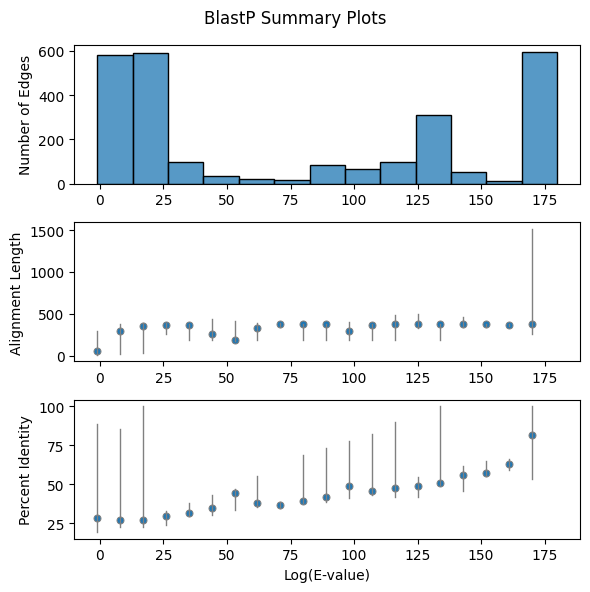

In [ ]:
fig, ax = plt.subplots(3, 1, figsize=(6,6), sharex=True)

sns.histplot(adh1_similarity_blastp, x="Log_E_Value", ax=ax[0])
sns.pointplot(adh1_similarity_blastp, x="Binned_Log_E_Value", y="Alignment_Length",
              ax=ax[1], linestyle='none', estimator="median", linewidth=1, color="grey",
              errorbar=lambda x: (x.min(), x.max()), native_scale=True,
              markerfacecolor="tab:blue", markersize=5
)
sns.pointplot(adh1_similarity_blastp, x="Binned_Log_E_Value", y="Percent_Identity",
              ax=ax[2], linestyle='none', estimator="median", linewidth=1, color="grey",
              errorbar=lambda x: (x.min(), x.max()), native_scale=True,
              markerfacecolor="tab:blue", markersize=5
)

ax[2].set_xlabel("Log(E-value)")
ax[0].set_ylabel("Number of Edges")
ax[1].set_ylabel("Alignment Length")
ax[2].set_ylabel("Percent Identity")

ax[0].tick_params(labelbottom=True)
ax[1].tick_params(labelbottom=True)

plt.suptitle("BlastP Summary Plots")
plt.tight_layout()

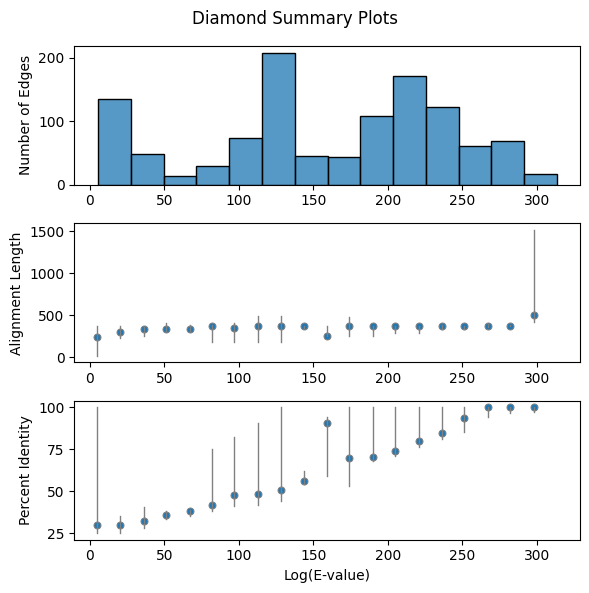

In [ ]:
fig, ax = plt.subplots(3, 1, figsize=(6,6), sharex=True)

sns.histplot(adh1_similarity_diamond, x="Log_E_Value", ax=ax[0])
sns.pointplot(adh1_similarity_diamond, x="Binned_Log_E_Value", y="Alignment_Length",
              ax=ax[1], linestyle='none', estimator="median", linewidth=1, color="grey",
              errorbar=lambda x: (x.min(), x.max()), native_scale=True,
              markerfacecolor="tab:blue", markersize=5
)
sns.pointplot(adh1_similarity_diamond, x="Binned_Log_E_Value", y="Percent_Identity",
              ax=ax[2], linestyle='none', estimator="median", linewidth=1, color="grey",
              errorbar=lambda x: (x.min(), x.max()), native_scale=True,
              markerfacecolor="tab:blue", markersize=5
)

ax[2].set_xlabel("Log(E-value)")
ax[0].set_ylabel("Number of Edges")
ax[1].set_ylabel("Alignment Length")
ax[2].set_ylabel("Percent Identity")

ax[0].tick_params(labelbottom=True)
ax[1].tick_params(labelbottom=True)

plt.suptitle("Diamond Summary Plots")
plt.tight_layout()

Text(0.5, 0.98, 'Correlation Between Sequence Similarity Algorithms')

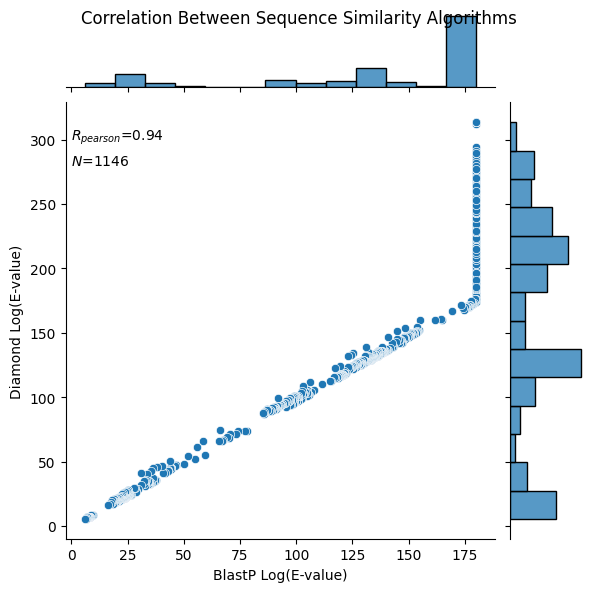

In [ ]:
joint_similarity = pd.merge(
    adh1_similarity_blastp[["Accession_1","Accession_2","Log_E_Value"]],
    adh1_similarity_diamond[["Accession_1","Accession_2","Log_E_Value"]],
    how="inner", on=["Accession_1","Accession_2"], suffixes=("_blastp","_diamond")
    )
pearson_r, pearson_p = pearsonr(
    joint_similarity["Log_E_Value_blastp"],
    joint_similarity["Log_E_Value_diamond"]
)
fig = sns.jointplot(
    joint_similarity, x="Log_E_Value_blastp", y="Log_E_Value_diamond",
)
fig.ax_joint.text(0, 300, "$R_{pearson}$=" + f"{pearson_r:.2}")
fig.ax_joint.text(0, 280, "$N$=" + f"{len(joint_similarity)}")
fig.ax_joint.set_xlabel("BlastP Log(E-value)")
fig.ax_joint.set_ylabel("Diamond Log(E-value)")
plt.suptitle("Correlation Between Sequence Similarity Algorithms")

BlastP and Diamond are highly correlated for the subset of sequence pairs identified using both tools. For highly similar sequences, the range of Diamond scores is larger where as BlastP returns a single max value. Diamond is 1 order of magnitude faster than BlastP, 300 ms vs 4000 ms; there are approximately 4 times the number of unique unfiltered pairwise comparisons identified using BlastP compared to Diamond.

# 03: Visualize Sequences

With nodes as sequences and edges as weighted sequence similarity between two nodes. We can color nodes using metadata from UniProt we previously fetched in section 01.

In [ ]:
def get_taxon_rank(taxonId, rank:str):
  "Retrieve rank from NCBI taxonId lineage."
  t = taxoniq.Taxon(taxonId)
  lineage_dict = {t.rank.name: t.scientific_name for t in t.ranked_lineage}
  try:
    return lineage_dict[rank]
  except:
    return None

def superkingdom_color_mapper(node_data):
  "Map superkingdom to hexcode color."
  superkingdom = node_data["properties"]["superkingdom"]
  if superkingdom is None:
    return "#808080"
  elif superkingdom == "Eukaryota":
    return "#ff6c00"
  elif superkingdom == "Bacteria":
    return "#76b041"
  elif superkingdom == "Archaea":
    return "#ffc914"
  return superkingdom

def kingdom_color_mapper(node_data):
  "Map kingdom to hexcode color."
  kingdom = node_data["properties"]["kingdom"]
  if kingdom is None:
    return "#808080"
  elif kingdom == "Viridiplantae":
    return "#628B48"
  elif kingdom == "Metazoa":
    return "#F9C22E"
  elif kingdom == "Fungi":
    return "#67597A"

  return kingdom

superkingdom_dict = {header: superkingdom for header, superkingdom in
 zip(
     adh1_df["Header"].to_list(),
     adh1_df["taxonId"].apply(get_taxon_rank, rank="superkingdom").to_list()
  )
}

kingdom_dict = {header: kingdom for header, kingdom in
 zip(
     adh1_df["Header"].to_list(),
     adh1_df["taxonId"].apply(get_taxon_rank, rank="kingdom").to_list()
  )
}

adh1_df["taxonId"].apply(get_taxon_rank, rank="kingdom").value_counts()

,count
taxonId,
Metazoa,43
Viridiplantae,26
Fungi,17


In [ ]:
pfam_dict = {header: pfam for header, pfam in
 zip(
     adh1_df["Header"].to_list(),
     adh1_df["Pfam"].str.join("|").to_list()
  )
}
colors = ["#ffc914", "#0b7189", "#ff6c00", '#76b041']
pfam_color_mapper_dict = {pfam: "#808080" for pfam in adh1_df["Pfam"].str.join("|").unique()}
pfam_color_mapper_dict = pfam_color_mapper_dict | {
  pfam: colors[i] for i, pfam in enumerate(adh1_df["Pfam"].str.join("|").value_counts()[:3].index)
}

def pfam_color_mapper(node_data):
  "Map pfam to color."
  return pfam_color_mapper_dict[node_data["properties"]["PFAM"]]

def edge_mapper(node_data):
  "Map all edges to color."
  return "#808080"

## Color SSN by PFAM

The UniProt PFAM metadata is a list of None, one or multiple PFAM predicted by Interproscan. For this analysis, convert the list to a string and add this string-ified PFAM to the nodes. Color the most prominent PFAMs.

- Yellow: [PF08240](https://www.ebi.ac.uk/interpro/entry/pfam/PF08240/)|[PF00107](https://www.ebi.ac.uk/interpro/entry/pfam/PF00107/): Alcohol dehydrogenase GroES-like domain & Zinc-binding dehydrogenase
- Blue: [PF00106](https://www.ebi.ac.uk/interpro/entry/pfam/PF00106/): short-chain dehydrogenase
- Orange: [PF25137](https://www.ebi.ac.uk/interpro/entry/pfam/PF25137/)|[PF00465](https://www.ebi.ac.uk/interpro/entry/pfam/PF00465/): C-terminal Fe-containing alcohol dehydrogenase & Iron-containing alcohol dehydrogenase
- Grey: Other/Missing data

### BlastP SSN colored by PFAM

1 major cluster of yellow sequences (Alcohol dehydrogenase GroES-like domain & Zinc-binding dehydrogenase) containing the *Saccharomyces cerevisiae*  ADH1 sequence, P00330.

1 minor cluster of yellow sequences (Alcohol dehydrogenase GroES-like domain & Zinc-binding dehydrogenase) with different sequence identity than sequences in the major cluster.

1 minor cluster of blue sequences (short-chain dehydrogenase) containing the *Drosophila virilis* (Fruit fly) ADH1 sequence, B4M870.

1 minor cluster of orange sequences (C-terminal Fe-containing alcohol dehydrogenase & Iron-containing alcohol dehydrogenase) containing the 	*Clostridium saccharobutylicum* sequence annotated as NADPH-dependent butanol dehydrogenase, P13604.

In [ ]:
g_blastp = nx.from_pandas_edgelist(
    adh1_similarity_blastp[["Accession_1","Accession_2","Log_E_Value"]].query("Log_E_Value > 75"),
    source="Accession_1", target="Accession_2", edge_attr="Log_E_Value"
)

nx.set_node_attributes(g_blastp, pfam_dict, "PFAM")
widget_blastp = GraphWidget(graph=g_blastp)
widget_blastp.set_node_color_mapping(pfam_color_mapper)

widget_blastp.set_edge_color_mapping(edge_mapper)
widget_blastp.organic_layout()
display(widget_blastp)

GraphWidget(layout=Layout(height='800px', width='100%'))

### Diamond SSN colored by PFAM

Very similar results as the BlastP SSN, very similarly size major and minor clusters with the same PFAM identities.

In [ ]:
g_diamond = nx.from_pandas_edgelist(
    adh1_similarity_diamond[["Accession_1","Accession_2","Log_E_Value"]].query("Log_E_Value > 60"),
    source="Accession_1", target="Accession_2", edge_attr="Log_E_Value"
)
nx.set_node_attributes(g_diamond, pfam_dict, "PFAM")

widget_diamond = GraphWidget(graph=g_diamond)
widget_diamond.set_node_color_mapping(pfam_color_mapper)

widget_diamond.set_edge_color_mapping(edge_mapper)
widget_diamond.organic_layout()
display(widget_diamond)

GraphWidget(layout=Layout(height='800px', width='100%'))

## Color SSN by Kingdom


The UniProt taxonID was used to retrieve the lineage and the kingdom rank was extracted for each sequence.

- Yellow: Metazoa
- Green: Viridiplantae
- Purple: Fungi
- Grey: Missing data


### BlastP SSN colored by Kingdom


Because the Blastp and Diamond SSN are very similar, we will analyze just BlastP.

The major cluster of PF08240|PF00107 (Alcohol dehydrogenase GroES-like domain & Zinc-binding dehydrogenase) contains all Eukaryota sequences from the Metazoa, Viridiplantae, and Fungi.

1 minor cluster of PF08240|PF00107 (Alcohol dehydrogenase GroES-like domain & Zinc-binding dehydrogenase) contains a majority of Fungi sequences.

The minor cluster of PF00106 (short-chain dehydrogenase) contains all Metazoa sequences.

1 minor cluster of PF25137|PF00465 (C-terminal Fe-containing alcohol dehydrogenase & Iron-containing alcohol dehydrogenase) contains 2 Fungi and 2
missing-kingdom-data sequences.

In [ ]:
g_blastp = nx.from_pandas_edgelist(
    adh1_similarity_blastp[["Accession_1","Accession_2","Log_E_Value"]].query("Log_E_Value > 75"),
    source="Accession_1", target="Accession_2", edge_attr="Log_E_Value"
)

nx.set_node_attributes(g_blastp, kingdom_dict, "kingdom")
widget_blastp = GraphWidget(graph=g_blastp)
widget_blastp.set_node_color_mapping(kingdom_color_mapper)

widget_blastp.set_edge_color_mapping(edge_mapper)
widget_blastp.organic_layout()
display(widget_blastp)

GraphWidget(layout=Layout(height='800px', width='100%'))

### BlastP SSN colored by Kingdom High Similarity


Increase the threshold on Log(E-value) to > 178 to include only the most significant pairwise sequences, reducing the number of total sequences. The previous major cluster is split into two large clusters 1 Metazoa and 1 Viridiplantae with the two Fungi sequences splitting off from two clusters.

The remaining minor cluster remain present but slightly reduced in size.

In [ ]:
g_blastp = nx.from_pandas_edgelist(
    adh1_similarity_blastp[["Accession_1","Accession_2","Log_E_Value"]].query("Log_E_Value > 178"),
    source="Accession_1", target="Accession_2", edge_attr="Log_E_Value"
)

nx.set_node_attributes(g_blastp, kingdom_dict, "kingdom")
widget_blastp = GraphWidget(graph=g_blastp)
widget_blastp.set_node_color_mapping(kingdom_color_mapper)

widget_blastp.set_edge_color_mapping(edge_mapper)
widget_blastp.organic_layout()
display(widget_blastp)

GraphWidget(layout=Layout(height='800px', width='100%'))